## Blind source separation project

This project aims to separate an image, formed as the sum of two images, into its original components.

The two source images, img1 and img2, are drawn from different datasets: MNIST and Fashion-MNIST, respectively.

No preprocessing is allowed. The neural network receives the combined image (img1 + img2) as input and outputs the predicted components (hat_img1,hat_img2).

Performance is evaluated using the mean squared error (MSE) between the predicted and ground-truth images.

Both datasets (MNIST and Fashion-MNIST) are grayscale. For simplicity, all samples are padded to a (32,32) resolution.

### Requirements
You can install the requirements libraries in the below cell.

In [ ]:
!pip install visualkeras
!pip install tensorflow
!pip install numpy
!pip install keras
!pip install matplotlib
!pip install scikit-learn

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import keras
from keras import layers, Model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import visualkeras

In [4]:
def load_dataset():
    (mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = keras.datasets.mnist.load_data()
    (fashion_mnist_x_train, fashion_mnist_y_train), (fashion_mnist_x_test, fashion_mnist_y_test) = keras.datasets.fashion_mnist.load_data()

    mnist_x = np.pad(np.concatenate([mnist_x_train, mnist_x_test]),((0,0),(2,2),(2,2)))/255.
    fashion_mnist_x = np.pad(np.concatenate([fashion_mnist_x_train, fashion_mnist_x_test]),((0,0),(2,2),(2,2)))/255.

    mnist_x_trainval, mnist_x_test, fashion_x_trainval, fashion_x_test = train_test_split(
        mnist_x, fashion_mnist_x, test_size=0.2, random_state=42
    )

    return mnist_x_trainval, mnist_x_test, fashion_x_trainval, fashion_x_test

In [5]:
def datagenerator(x1, x2, batchsize):
    n1 = x1.shape[0]
    n2 = x2.shape[0]
    while True:
        num1 = np.random.randint(0, n1, batchsize)
        num2 = np.random.randint(0, n2, batchsize)

        x_data = (x1[num1] + x2[num2]) / 2.0
        y_data = (x1[num1], x2[num2])

        yield x_data, y_data

In [6]:
mnist_x_trainval, mnist_x_test, fashion_x_trainval, fashion_x_test = load_dataset()
onegen = datagenerator(mnist_x_test, fashion_x_test, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


This is a graphical example from a simple generator that shows what's the goal of the project. We aims to separate the two images from the input one.

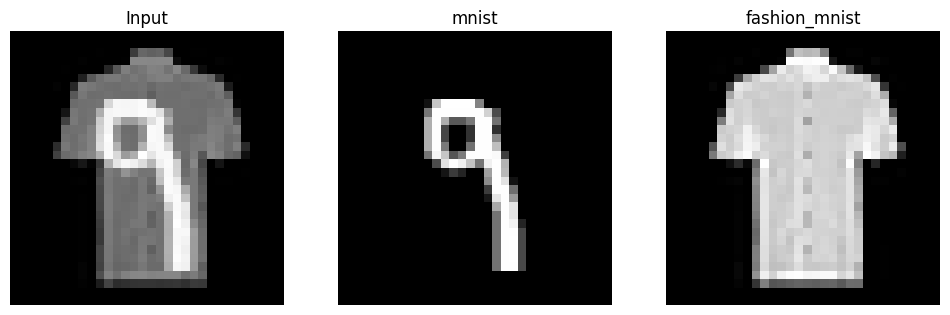

In [7]:
def show_images(x,y1,y2):
    fig, ax = plt.subplots(1,3,figsize=(12,4))
    ax[0].imshow(x,cmap='gray')
    ax[0].title.set_text('Input')
    ax[0].axis('off')
    ax[1].imshow(y1,cmap='gray')
    ax[1].title.set_text('mnist')
    ax[1].axis('off')
    ax[2].imshow(y2,cmap='gray')
    ax[2].title.set_text('fashion_mnist')
    ax[2].axis('off')
    plt.show()

x,(y1,y2)=next(onegen)
show_images(x[0],y1[0],y2[0])

### Encoder Decoder model
The model I decided to create is a encoder-decoder model with a dual-decoder structure. Its goal is to take a single grayscale image (32x32x1), representing the combination of two source images, and output two separate reconstructed images (one for MNIST and one for Fashion MNIST).

Input and Encoder:
* The model begins with an input layer for a 32×32 grayscale image.
* It passes the image through three encoder blocks. In each block:
    * Two convolutional layers (with increasing numbers of filters: 64, 128, and 256, respectively) extract low‐level to high–level features.
    * Batch normalization and LeakyReLU activation are applied after each convolution to speed up convergence and improve stability.
    * A max pooling layer then downsamples the spatial dimensions.
    * Dropout is used to regularize the network.
* The outputs right before pooling (referred to as skip connections) are saved (skip1, skip2, and skip3) for later use in the decoders.

Dual Decoders:

The encoded representation is fed into two parallel decoders. One for reconstructing the MNIST image and one for the Fashion MNIST image. 

Each decoder follows a similar structure:
* Upsampling: Transposed convolution (deconvolution) layers upsample the feature maps back toward the original spatial dimensions.
* Skip Connections: At each upsampling stage, the decoder concatenates the corresponding saved feature maps from the encoder. This helps restore fine spatial details that might have been lost during pooling.
* Convolutions and Activations: After concatenation, additional convolutional layers along with batch normalization and LeakyReLU further refine the features. Dropout is also applied to reduce overfitting.
* Finally, in the output layer, a 1×1 convolution with sigmoid activation produces the output image for each branch (named “mnist_output” and “fashion_output”) so that pixel values fall between 0 and 1


In [4]:
def encoder_decoder_model():
    inputs = layers.Input(shape=(32, 32, 1))

    # encoder - block 1
    x = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    skip1 = x
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.1)(x)

    # encoder - block 2
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    skip2 = x
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.1)(x)

    # encoder - block 3
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    skip3 = x
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    encoded = x

    # decoder mnist - block 1
    x1 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(encoded)
    x1 = layers.concatenate([x1, skip3])
    x1 = layers.Conv2D(256, (3, 3), padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)
    x1 = layers.Conv2D(256, (3, 3), padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)
    x1 = layers.Dropout(0.2)(x1)

    # decoder mnist - block 2
    x1 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(x1)
    x1 = layers.concatenate([x1, skip2])
    x1 = layers.Conv2D(128, (3, 3), padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)
    x1 = layers.Conv2D(128, (3, 3), padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)
    x1 = layers.Dropout(0.1)(x1)

    # decoder mnist - block 3
    x1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(x1)
    x1 = layers.concatenate([x1, skip1])
    x1 = layers.Conv2D(64, (3, 3), padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)
    x1 = layers.Conv2D(64, (3, 3), padding='same')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(alpha=0.2)(x1)

    output_mnist = layers.Conv2D(1, (1, 1), activation='sigmoid', name='mnist_output')(x1)

    # decoder fashion mnist - block 1
    x2 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(encoded)
    x2 = layers.concatenate([x2, skip3])
    x2 = layers.Conv2D(256, (3, 3), padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)
    x2 = layers.Conv2D(256, (3, 3), padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)
    x2 = layers.Dropout(0.2)(x2)

    # decoder fashion mnist - block 2
    x2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(x2)
    x2 = layers.concatenate([x2, skip2])
    x2 = layers.Conv2D(128, (3, 3), padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)
    x2 = layers.Conv2D(128, (3, 3), padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)
    x2 = layers.Dropout(0.1)(x2)

    # decoder fashion mnist - block 3
    x2 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(x2)
    x2 = layers.concatenate([x2, skip1])
    x2 = layers.Conv2D(64, (3, 3), padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)
    x2 = layers.Conv2D(64, (3, 3), padding='same')(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(alpha=0.2)(x2)

    output_fashion_mnist = layers.Conv2D(1, (1, 1), activation='sigmoid', name='fashion_output')(x2)

    model = Model(inputs=inputs, outputs=[output_mnist, output_fashion_mnist])
    return model

In [26]:
def train(mnist_x_trainval, fashion_x_trainval, batch_size=32, epochs=100):
    mnist_x_train, mnist_x_val, fashion_x_train, fashion_x_val = train_test_split(
        mnist_x_trainval, fashion_x_trainval, test_size=0.1, random_state=42
    )

    train_generator = datagenerator(mnist_x_train, fashion_x_train, batch_size)
    val_generator = datagenerator(mnist_x_val, fashion_x_val, batch_size)

    model = encoder_decoder_model()
    model.summary()
    model.compile(
        optimizer=tf.optimizers.Adam(learning_rate=0.001),
        loss={
            'mnist_output': 'mse',
            'fashion_output': 'mse'
        },
        loss_weights={
            'mnist_output': 1.0,
            'fashion_output': 1.0
        }
    )

    callbacks = [
        keras.callbacks.ModelCheckpoint(
            'best_model.h5',
            monitor='val_loss',
            mode='min',
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_generator,
        steps_per_epoch=3000,
        epochs=epochs,
        validation_data=val_generator,
        validation_steps=3000,
        callbacks=callbacks,
        verbose=1
    )

    return model, history

In [27]:
model, history = train(mnist_x_trainval, fashion_x_trainval, batch_size=32, epochs=100)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 32, 32, 1)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_108 (Conv2D)       │ (None, 32, 32, 64)     │            640 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_108   │ (None, 32, 32, 64)     │            256 │ conv2d_108[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_108           │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_109 (Conv2D)       │ (None, 32, 32, 64)     │         36,928 │ leaky_re_lu_108[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_109   │ (None, 32, 32, 64)     │            256 │ conv2d_109[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_109           │ (None, 32, 32, 64)     │              0 │ batch_normalization_1… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_18          │ (None, 16, 16, 64)     │              0 │ leaky_re_lu_109[0][0]  │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_42 (Dropout)      │ (None, 16, 16, 64)     │              0 │ max_pooling2d_18[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_110 (Conv2D)       │ (None, 16, 16, 128)    │         73,856 │ dropout_42[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_110   │ (None, 16, 16, 128)    │            512 │ conv2d_110[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_110           │ (None, 16, 16, 128)    │              0 │ batch_normalization_1… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_111 (Conv2D)       │ (None, 16, 16, 128)    │        147,584 │ leaky_re_lu_110[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_111   │ (None, 16, 16, 128)    │            512 │ conv2d_111[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_111           │ (None, 16, 16, 128)    │              0 │ batch_normalization_1… │
│ (LeakyReLU)          

 Total params: 6,654,658 (25.39 MB)

 Trainable params: 6,649,282 (25.36 MB)

...

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 184s 61ms/step - fashion_output_loss: 4.5695e-04 - loss: 8.8769e-04 - mnist_output_loss: 4.3074e-04 - val_fashion_output_loss: 4.3245e-04 - val_loss: 8.4213e-04 - val_mnist_output_loss: 4.0969e-04 - learning_rate: 7.8125e-06
Epoch 54/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - fashion_output_loss: 4.6437e-04 - loss: 9.0063e-04 - mnist_output_loss: 4.3626e-04
Epoch 54: val_loss did not improve from 0.00084
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 185s 62ms/step - fashion_output_loss: 4.6437e-04 - loss: 9.0062e-04 - mnist_output_loss: 4.3625e-04 - val_fashion_output_loss: 4.3310e-04 - val_loss: 8.4425e-04 - val_mnist_output_loss: 4.1115e-04 - learning_rate: 7.8125e-06
Epoch 55/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - fashion_output_loss: 4.6092e-04 - loss: 8.9433e-04 - mnist_output_loss: 4.3341e-04
Epoch 55: val_loss did not improve from 0.00084
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 191s 64ms/step - fashion_output_loss: 4.6092e-04 - loss: 8.9433e-04 - mnist_o

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - fashion_output_loss: 4.5592e-04 - loss: 8.8510e-04 - mnist_output_loss: 4.2917e-04 - val_fashion_output_loss: 4.3212e-04 - val_loss: 8.4211e-04 - val_mnist_output_loss: 4.0998e-04 - learning_rate: 3.9063e-06
Epoch 60/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - fashion_output_loss: 4.5050e-04 - loss: 8.7500e-04 - mnist_output_loss: 4.2450e-04
Epoch 60: val_loss improved from 0.00084 to 0.00084, saving model to best_model.h5


3000/3000 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - fashion_output_loss: 4.5050e-04 - loss: 8.7500e-04 - mnist_output_loss: 4.2450e-04 - val_fashion_output_loss: 4.3215e-04 - val_loss: 8.4102e-04 - val_mnist_output_loss: 4.0887e-04 - learning_rate: 3.9063e-06
Epoch 61/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - fashion_output_loss: 4.6249e-04 - loss: 8.9798e-04 - mnist_output_loss: 4.3549e-04
Epoch 61: val_loss did not improve from 0.00084
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - fashion_output_loss: 4.6249e-04 - loss: 8.9798e-04 - mnist_output_loss: 4.3549e-04 - val_fashion_output_loss: 4.3336e-04 - val_loss: 8.4464e-04 - val_mnist_output_loss: 4.1128e-04 - learning_rate: 3.9063e-06
Epoch 62/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - fashion_output_loss: 4.5642e-04 - loss: 8.8732e-04 - mnist_output_loss: 4.3090e-04
Epoch 62: val_loss did not improve from 0.00084

Epoch 62: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
3000/3000 ━━━━━━━━━━━━━━━━━━━

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - fashion_output_loss: 4.5810e-04 - loss: 8.8923e-04 - mnist_output_loss: 4.3113e-04 - val_fashion_output_loss: 4.3113e-04 - val_loss: 8.3911e-04 - val_mnist_output_loss: 4.0799e-04 - learning_rate: 1.0000e-06
Epoch 72/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - fashion_output_loss: 4.5883e-04 - loss: 8.9024e-04 - mnist_output_loss: 4.3141e-04
Epoch 72: val_loss improved from 0.00084 to 0.00084, saving model to best_model.h5


3000/3000 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - fashion_output_loss: 4.5883e-04 - loss: 8.9025e-04 - mnist_output_loss: 4.3141e-04 - val_fashion_output_loss: 4.3037e-04 - val_loss: 8.3875e-04 - val_mnist_output_loss: 4.0838e-04 - learning_rate: 1.0000e-06
Epoch 73/100
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - fashion_output_loss: 4.5661e-04 - loss: 8.8649e-04 - mnist_output_loss: 4.2988e-04
Epoch 73: val_loss did not improve from 0.00084
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 194s 65ms/step - fashion_output_loss: 4.5660e-04 - loss: 8.8649e-04 - mnist_output_loss: 4.2988e-04 - val_fashion_output_loss: 4.3466e-04 - val_loss: 8.4751e-04 - val_mnist_output_loss: 4.1285e-04 - learning_rate: 1.0000e-06
Epoch 74/100
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - fashion_output_loss: 4.5662e-04 - loss: 8.8765e-04 - mnist_output_loss: 4.3103e-04
Epoch 74: val_loss did not improve from 0.00084
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 187s 62ms/step - fashion_output_loss: 4.5662e-04 - loss: 8.8765e-04 - mnist_o

### Model visualization
In the cell below is possible to visualize a representation of my model for this experiment.

2025-02-10 11:23:58.365579: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-02-10 11:23:58.365608: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-02-10 11:23:58.365627: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (Max): /proc/driver/nvidia/version does not exist
2025-02-10 11:23:58.366335: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/max/.local/lib/python3.10/site-packages/visualkeras/layered.py:86

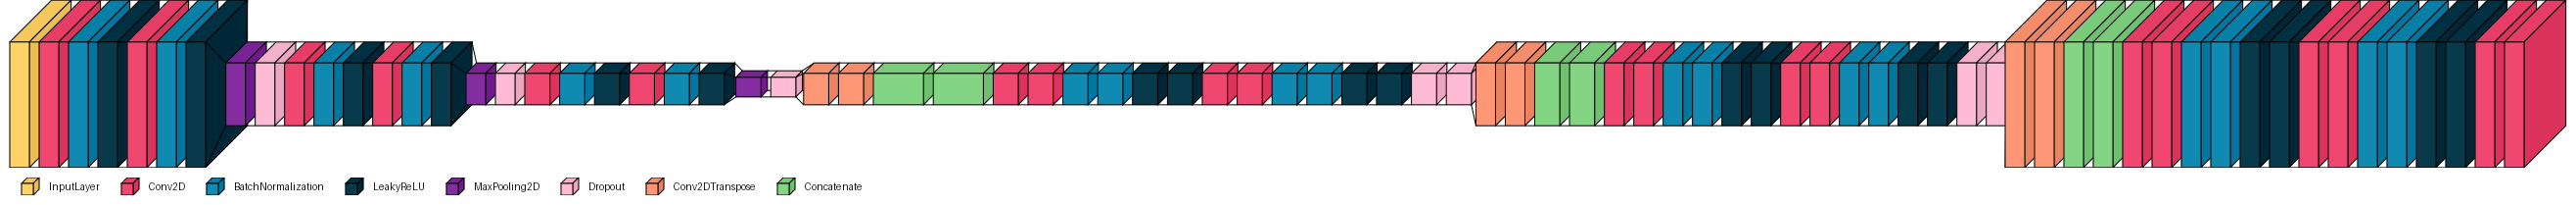

In [5]:
model = encoder_decoder_model()
visualkeras.layered_view(model, legend=True)

### Results on test set
The results on the test set shows that the model understood pretty well to get a MSE error of 0.00042. It indicates that, on average, the model's predictions are very close to the ground truth. The standard deviation is pretty low, 0.0000057. It shows that the performance is consistent across different test examples.  

In [63]:
testgen = datagenerator(mnist_x_test, fashion_x_test, 5000)

In [73]:
def eval_model(model, num_repeats=10):
    eval_results = []
    for i in range(num_repeats):
        x, (y1, y2) = next(testgen)

        pred1, pred2 = model.predict(x, verbose=0)
        pred1 = np.squeeze(pred1)
        pred2 = np.squeeze(pred2)

        mse = (np.mean((pred1 - y1)**2) + np.mean((pred2 - y2)**2)) / 2
        eval_results.append(mse)

    mean_mse = np.mean(eval_results)
    std_mse = np.std(eval_results)

    print(f"MSE = {mean_mse:.10f}")
    print(f"Standard deviation = {std_mse:.10f}")

    return mean_mse, std_mse, eval_results

In [75]:
mean_mse, std_mse, all_results = eval_model(model=model, num_repeats=10)

MSE = 0.0004269973
Standard deviation = 0.0000057204


This is how the traning and validation losses evolve during the model's training. 

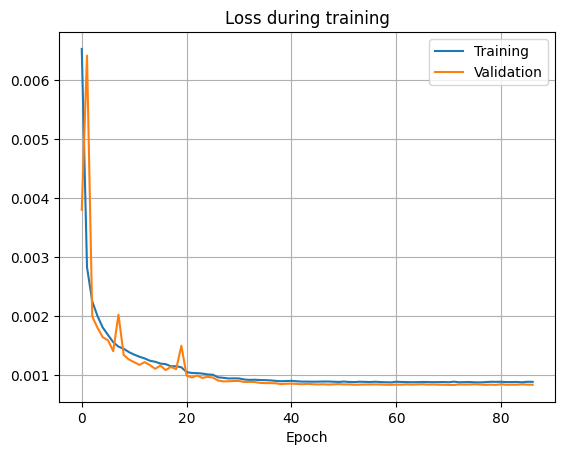

In [68]:
def display_history(history):
    loss_training = history.history['loss']
    loss_val = history.history['val_loss']

    plt.plot(loss_training)
    plt.plot(loss_val)
    plt.grid()
    plt.title('Loss during training')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'])
    plt.show()

display_history(history)

### Visual predictions
In the below cell is shown the visual predictions of my model.

In [76]:
def visualize_results(model, num_samples=3):
    x, (y1, y2) = next(testgen)
    y1_pred, y2_pred = model.predict(x)

    for i in range(num_samples):
        plt.figure(figsize=(12, 3))

        plt.subplot(1, 4, 1)
        plt.imshow(x[i], cmap='gray')
        plt.title('Mixed Input')
        plt.axis('off')

        plt.subplot(1, 4, 2)
        plt.imshow(y1_pred[i].reshape(32, 32), cmap='gray')
        plt.title('MNIST Prediction')
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(y2_pred[i].reshape(32, 32), cmap='gray')
        plt.title('Fashion Prediction')
        plt.axis('off')

        plt.subplot(1, 4, 4)
        diff = x[i] - y1_pred[i].reshape(32, 32)
        plt.imshow(diff, cmap='gray')
        plt.title('Difference')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


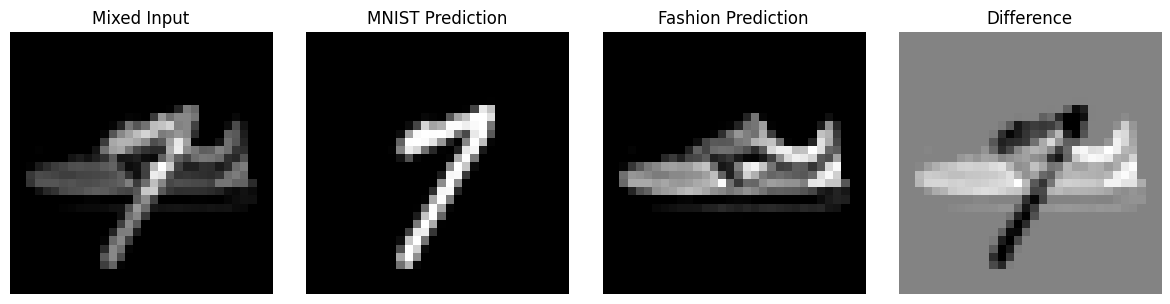

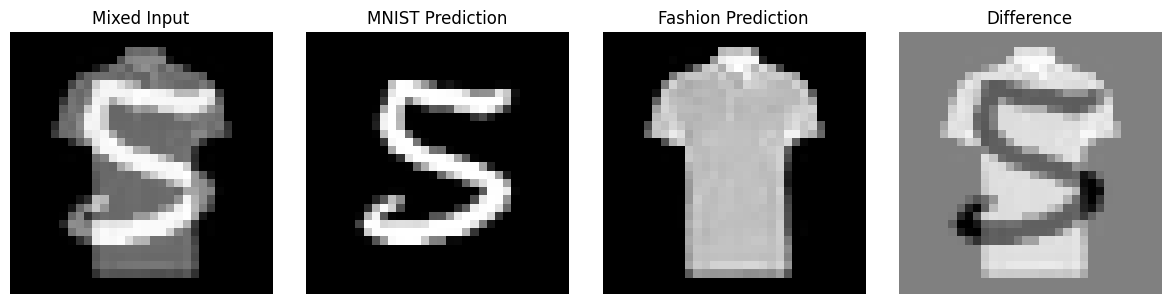

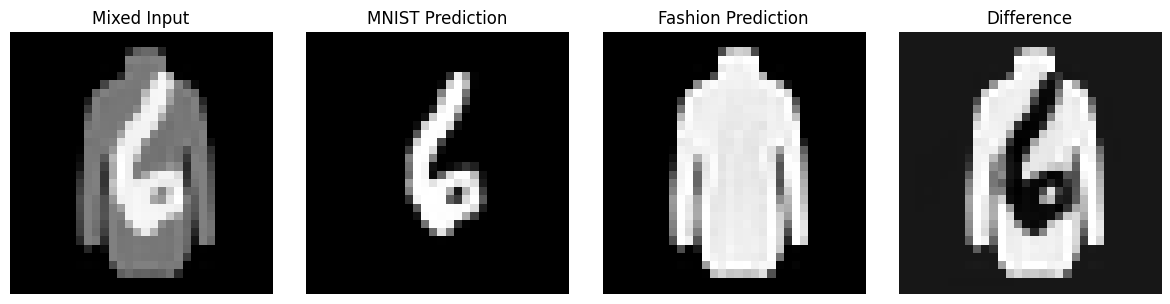

In [77]:
visualize_results(model)